Project 5.19: The Classical Helium Atom <br>
Simulation and Modeling

**Abstract** <br>
The helium atom provides one of the simplest examples of a three-body problem in physics. By treating the two electrons classically and fixing the heavy nucleus at the origin, we reduce the system to a set of coupled ODEs governing the electron positions and velocities in two dimensions. We integrate these equations using the adaptive RK45 (Dormand-Prince) method and investigate the variety of orbital behaviors the system can exhibit, from stable braiding orbits to chaotic autoionization. In particular, we examine the sensitivity of the ionization time to initial conditions and find evidence of self-similar, fractal-like structure characteristic of chaotic dynamics.

**Introduction** <br>
The classical helium atom consists of a nucleus with charge $Z=2$ and two electrons, each with unit mass and unit charge. If we ignore the small motion of the heavy nucleus, we can fix it at the origin and write the equations of motion for each electron. Each electron is attracted to the nucleus and repelled by the other electron. In atomic units where the electron mass and charge are both unity, the accelerations are:

$$\mathbf{a}_1 = -\frac{2\,\mathbf{r}_1}{r_1^3} + \frac{\mathbf{r}_1 - \mathbf{r}_2}{r_{12}^3}$$

$$\mathbf{a}_2 = -\frac{2\,\mathbf{r}_2}{r_2^3} + \frac{\mathbf{r}_2 - \mathbf{r}_1}{r_{12}^3}$$

where $\mathbf{r}_1$ and $\mathbf{r}_2$ are the position vectors of the two electrons measured from the nucleus, and $r_{12} = |\mathbf{r}_1 - \mathbf{r}_2|$ is the distance between them. The first term in each equation is the Coulomb attraction to the $Z=2$ nucleus, and the second term is the electron-electron repulsion. The force between two unit charges separated by distance $r$ is $|F| = 1/r^2$, which differs from the gravitational analogue in that the inter-body force is repulsive rather than attractive.

We restrict the problem to two dimensions for simplicity, giving each electron two position and two velocity components. The full state vector is thus 8-dimensional: $[x_1, y_1, x_2, y_2, v_{x1}, v_{y1}, v_{x2}, v_{y2}]$. We investigate a range of initial conditions that produce qualitatively different behavior, including planetary-like orbits, braiding patterns, complex trajectories, and chaotic autoionization.

**Methods** <br>
Because the electrons can pass very close to the nucleus, their accelerations can become extremely large, requiring very small time steps during close encounters but allowing larger steps when the electrons are far apart. A fixed time step would either be too slow (if chosen small enough for close passages) or inaccurate (if chosen large for efficiency). This makes an adaptive step size algorithm essential.

We use the RK45 method, specifically the Dormand-Prince variant as described in Numerical Recipes (Section 17.2). This is a 6-stage embedded Runge-Kutta method that produces both a 5th-order and a 4th-order solution at each step. The difference between the two estimates provides a local error estimate without any additional function evaluations. The step size is then adjusted using the controller:

$$h_{n+1} = h_n \cdot S \cdot \text{err}^{-\alpha}$$

where $S = 0.9$ is a safety factor and $\alpha = 0.2$ for a 5th-order method. The error is computed as an RMS norm scaled by both absolute and relative tolerances (both set to $10^{-9}$). If the error exceeds 1, the step is rejected and retried with a smaller $h$. The initial step size is $\Delta t = 0.001$ as specified in the problem.

The implementation of this solver is contained in `ode.py`, specifically the `solve_ode_rk45` function, which was developed in a previous assignment. For part (d), where we need to run many simulations with early termination upon ionization, we inline the RK45 loop to avoid storing the full trajectory and to allow breaking out as soon as either electron exceeds a distance of 6 from the nucleus.

To verify that our integration is correct, we monitor two conserved quantities. The total energy of the system is:

$$E = \frac{1}{2}(v_1^2 + v_2^2) - \frac{2}{r_1} - \frac{2}{r_2} + \frac{1}{r_{12}}$$

and the total $z$-component of angular momentum (the only component in 2D) is:

$$L_z = (x_1 v_{y1} - y_1 v_{x1}) + (x_2 v_{y2} - y_2 v_{x2})$$

Both should remain constant throughout the integration if the solver is working correctly.

We begin by defining the derivative function and our conservation diagnostics.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ode import solve_ode_rk45
%matplotlib inline

In [12]:
def helium_derivs(t, y, p):
    """
    Derivatives for the 2D classical helium atom.
    State vector: [x1, y1, x2, y2, vx1, vy1, vx2, vy2]
    Returns:      [vx1, vy1, vx2, vy2, ax1, ay1, ax2, ay2]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y

    r1_vec = np.array([x1, y1])
    r2_vec = np.array([x2, y2])
    r12_vec = r1_vec - r2_vec

    r1 = np.linalg.norm(r1_vec)
    r2 = np.linalg.norm(r2_vec)
    r12 = np.linalg.norm(r12_vec)

    # Eq 5.33: nucleus attraction + electron-electron repulsion
    a1 = -2.0 * r1_vec / r1**3 + r12_vec / r12**3
    a2 = -2.0 * r2_vec / r2**3 - r12_vec / r12**3

    return np.array([vx1, vy1, vx2, vy2, a1[0], a1[1], a2[0], a2[1]])


def total_energy(y_array):
    """Compute total energy (KE + PE) at each time step."""
    E = np.zeros(len(y_array))
    for i in range(len(y_array)):
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y_array[i]
        r1 = np.sqrt(x1**2 + y1**2)
        r2 = np.sqrt(x2**2 + y2**2)
        r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        KE = 0.5 * (vx1**2 + vy1**2 + vx2**2 + vy2**2)
        PE = -2.0/r1 - 2.0/r2 + 1.0/r12
        E[i] = KE + PE
    return E


def total_angular_momentum(y_array):
    """Compute total L_z at each time step (2D -> only z-component)."""
    L = np.zeros(len(y_array))
    for i in range(len(y_array)):
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y_array[i]
        L[i] = (x1*vy1 - y1*vx1) + (x2*vy2 - y2*vx2)
    return L

p = {}  # empty parameter dict required by solve_ode_rk45

**Analysis**

**(a) Basic Simulation** <br>
We simulate the helium atom with initial conditions $\mathbf{r}_1 = (2,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_1 = (0, 0.95)$, and $\mathbf{v}_2 = (0, -1)$ with $\Delta t = 0.001$. These initial conditions place the two electrons on opposite sides of the nucleus with opposing velocities, similar to a mini-solar system configuration. We run the simulation to $t = 50$ and check energy conservation.

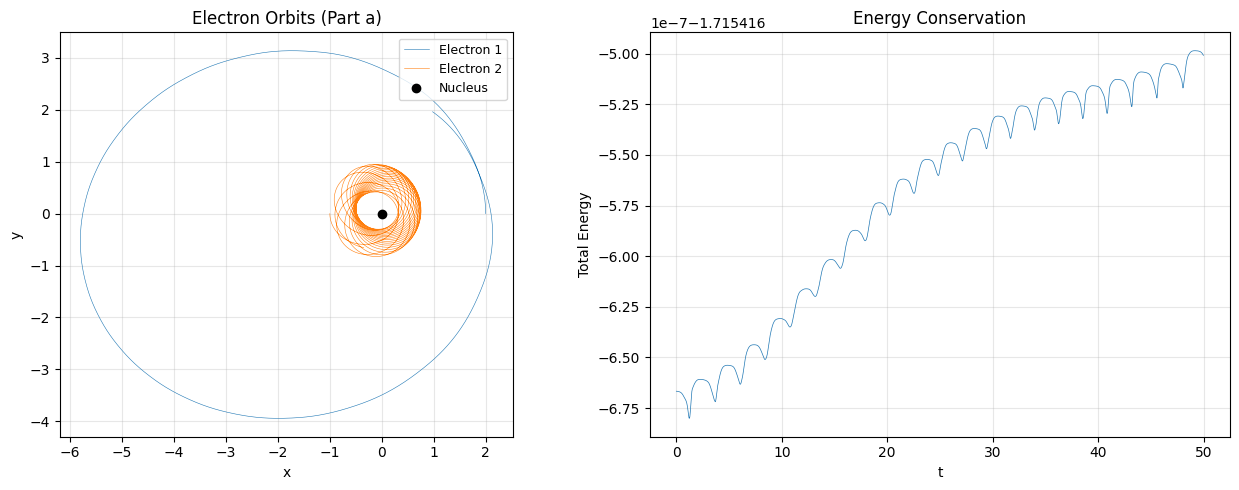

Energy: initial = -1.715417, final = -1.715417, relative change = 9.67e-08
Number of adaptive steps taken: 2059


In [13]:
y0_a = [2.0, 0.0, -1.0, 0.0, 0.0, 0.95, 0.0, -1.0]
t_a, y_a = solve_ode_rk45(helium_derivs, [0, 50], y0_a, p, h_init=0.001)

E_a = total_energy(y_a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(y_a[:, 0], y_a[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[0].plot(y_a[:, 2], y_a[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[0].plot(0, 0, 'ko', ms=6, label='Nucleus')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Electron Orbits (Part a)')
axes[0].legend(fontsize=9)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_a, E_a, lw=0.5)
axes[1].set_xlabel('t')
axes[1].set_ylabel('Total Energy')
axes[1].set_title('Energy Conservation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Energy: initial = {E_a[0]:.6f}, final = {E_a[-1]:.6f}, "
      f"relative change = {abs((E_a[-1]-E_a[0])/E_a[0]):.2e}")
print(f"Number of adaptive steps taken: {len(t_a)}")

The orbits resemble a mini-solar system: electron 1 follows a wide orbit while electron 2 stays close to the nucleus. The energy is conserved to a relative change on the order of $10^{-8}$, which confirms that the adaptive RK45 solver is working correctly with our chosen tolerances. The energy plot axis label shows fluctuations at the $10^{-7}$ level around the initial value, which is consistent with the local truncation error of the method.

**(b) Braiding Orbits and Autoionization** <br>
The initial condition $\mathbf{r}_1 = (1.4,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_1 = (0, 0.86)$, $\mathbf{v}_2 = (0, -1)$ is reported to produce braiding orbits. We simulate this and then perturb $v_{1y}$ by $\pm 0.02$ to observe how small changes destroy the stable pattern and lead to autoionization, where one electron gains enough energy to escape the atom.

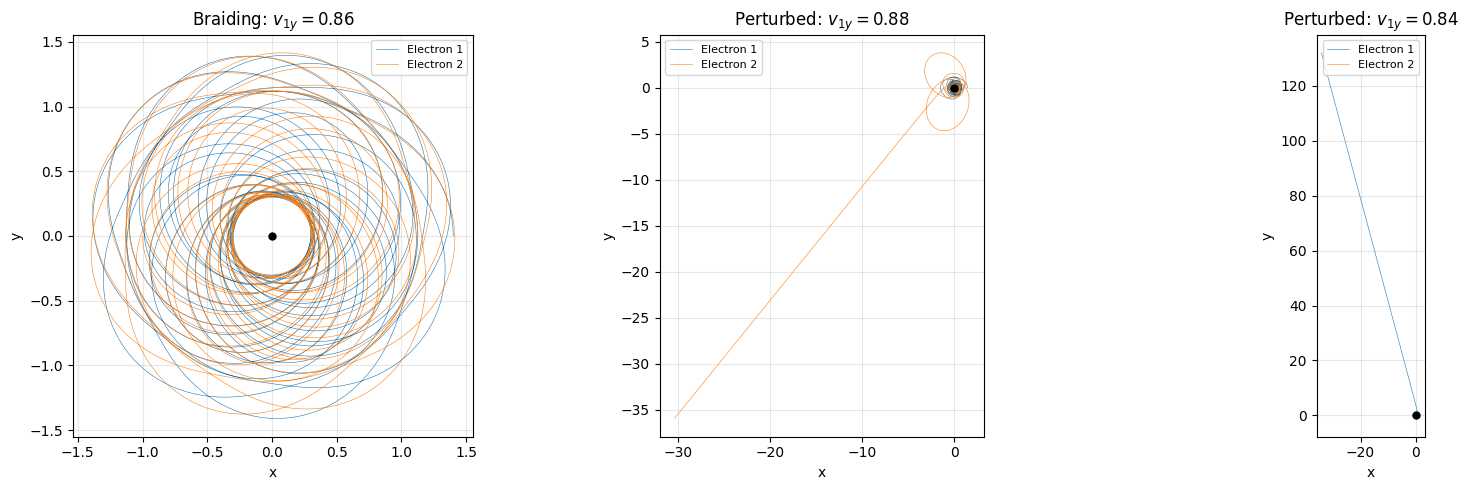

In [14]:
# Braiding orbit
y0_b = [1.4, 0.0, -1.0, 0.0, 0.0, 0.86, 0.0, -1.0]
t_b, y_b = solve_ode_rk45(helium_derivs, [0, 100], y0_b, p, h_init=0.001)

# Perturbed cases
y0_b_up = [1.4, 0.0, -1.0, 0.0, 0.0, 0.88, 0.0, -1.0]
t_b_up, y_b_up = solve_ode_rk45(helium_derivs, [0, 100], y0_b_up, p, h_init=0.001)

y0_b_dn = [1.4, 0.0, -1.0, 0.0, 0.0, 0.84, 0.0, -1.0]
t_b_dn, y_b_dn = solve_ode_rk45(helium_derivs, [0, 100], y0_b_dn, p, h_init=0.001)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, ydata, title in zip(axes,
        [y_b, y_b_up, y_b_dn],
        ['Braiding: $v_{1y}=0.86$',
         'Perturbed: $v_{1y}=0.88$',
         'Perturbed: $v_{1y}=0.84$']):
    ax.plot(ydata[:, 0], ydata[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
    ax.plot(ydata[:, 2], ydata[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
    ax.plot(0, 0, 'ko', ms=5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The unperturbed initial condition produces a striking braiding pattern where both electrons weave around the nucleus in interleaved loops. Even a change of $\pm 0.02$ in $v_{1y}$ is enough to destroy this pattern: in both perturbed cases, one electron eventually gains enough energy from a close encounter to escape the atom entirely (autoionization). This sensitivity to initial conditions is a hallmark of chaotic dynamics in this three-body system.

**(c) Complex Orbits and Angular Momentum** <br>
We investigate two more initial conditions that produce complex orbits and check whether the total angular momentum is conserved.

First: $\mathbf{r}_1 = (3,0)$, $\mathbf{r}_2 = (1,0)$, $\mathbf{v}_1 = (0, 0.4)$, $\mathbf{v}_2 = (0, -1)$. <br>
Second: $\mathbf{r}_1 = (2.5,0)$, $\mathbf{r}_2 = (1,0)$, $\mathbf{v}_1 = (0, 0.4)$, $\mathbf{v}_2 = (0, -1)$.

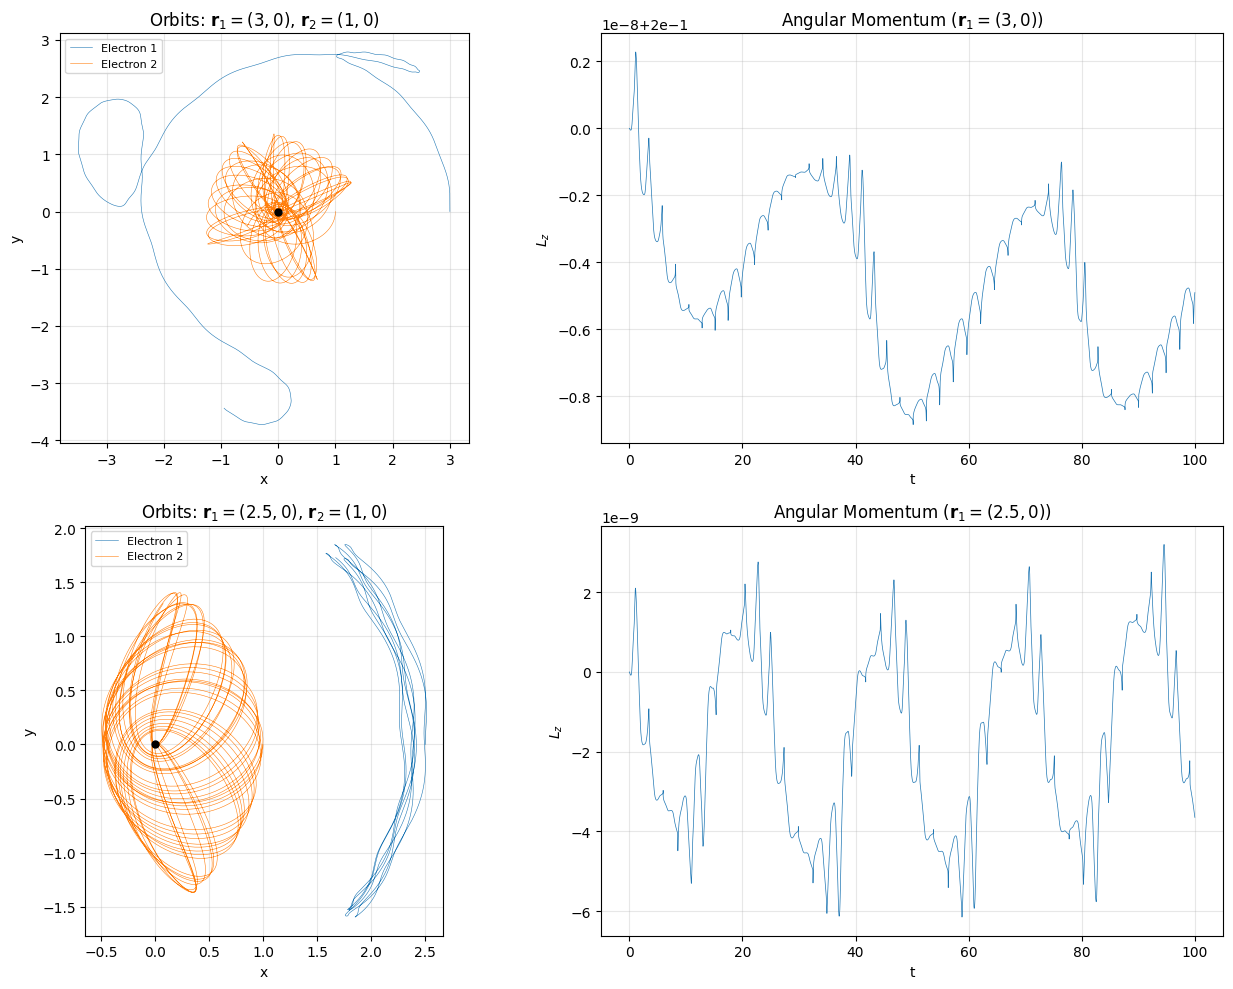

IC 1 -- L_z: initial = 0.200000, max deviation = 8.85e-09
IC 2 -- L_z: initial = 0.000000, max deviation = 6.15e-09


In [15]:
y0_c1 = [3.0, 0.0, 1.0, 0.0, 0.0, 0.4, 0.0, -1.0]
t_c1, y_c1 = solve_ode_rk45(helium_derivs, [0, 100], y0_c1, p, h_init=0.001)

y0_c2 = [2.5, 0.0, 1.0, 0.0, 0.0, 0.4, 0.0, -1.0]
t_c2, y_c2 = solve_ode_rk45(helium_derivs, [0, 100], y0_c2, p, h_init=0.001)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# IC 1: orbits
axes[0, 0].plot(y_c1[:, 0], y_c1[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[0, 0].plot(y_c1[:, 2], y_c1[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[0, 0].plot(0, 0, 'ko', ms=5)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('Orbits: $\\mathbf{r}_1=(3,0)$, $\\mathbf{r}_2=(1,0)$')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

# IC 1: angular momentum
L_c1 = total_angular_momentum(y_c1)
axes[0, 1].plot(t_c1, L_c1, lw=0.5)
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('$L_z$')
axes[0, 1].set_title('Angular Momentum ($\\mathbf{r}_1=(3,0)$)')
axes[0, 1].grid(True, alpha=0.3)

# IC 2: orbits
axes[1, 0].plot(y_c2[:, 0], y_c2[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[1, 0].plot(y_c2[:, 2], y_c2[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[1, 0].plot(0, 0, 'ko', ms=5)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Orbits: $\\mathbf{r}_1=(2.5,0)$, $\\mathbf{r}_2=(1,0)$')
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

# IC 2: angular momentum
L_c2 = total_angular_momentum(y_c2)
axes[1, 1].plot(t_c2, L_c2, lw=0.5)
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('$L_z$')
axes[1, 1].set_title('Angular Momentum ($\\mathbf{r}_1=(2.5,0)$)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"IC 1 -- L_z: initial = {L_c1[0]:.6f}, max deviation = {np.max(np.abs(L_c1 - L_c1[0])):.2e}")
print(f"IC 2 -- L_z: initial = {L_c2[0]:.6f}, max deviation = {np.max(np.abs(L_c2 - L_c2[0])):.2e}")

Both sets of initial conditions produce complex, non-repeating orbits. The angular momentum plots may appear to fluctuate, but the axis scales reveal that these variations are at the $10^{-8}$ to $10^{-9}$ level, which is consistent with the tolerance of our RK45 solver. In other words, angular momentum is conserved to numerical precision. This is expected because all forces in the system (nucleus-electron and electron-electron Coulomb interactions) are central forces directed along the line connecting the interacting particles, so there is no external torque on the system.

Note that the first initial condition has $L_z = 3(0.4) - 1(1) = 0.2$, while the second has $L_z = 2.5(0.4) - 1(1) = 0.0$. Zero total angular momentum does not prevent complex motion, as the individual electrons can still exchange angular momentum between themselves.

**(d) Ionization Time vs. Initial Velocity** <br>
We fix $\mathbf{r}_1 = (2,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_2 = (0,-1)$ and vary $\mathbf{v}_1 = (v_{1x}, 0)$ from $v_{1x} = 0.6$ to $1.3$ in steps of $\Delta v = 0.02$. For each initial condition, we integrate until either electron exceeds a distance of $6$ from the nucleus (autoionization) or until $t = 2000$. We use `solve_ode_rk45` from `ode.py`, integrating in chunks and checking for ionization after each chunk to avoid storing unnecessarily large trajectory arrays.

In [16]:
def ionization_time(v1x, t_max=2000.0, r_max=6.0, chunk=50.0, h_init=0.001):
    """
    Integrate the helium atom using solve_ode_rk45 from ode.py and return the 
    time at which ionization occurs (either electron exceeds r_max from nucleus).
    Returns t_max if no ionization occurs within the time limit.
    
    We integrate in chunks to avoid storing a massive trajectory array
    for the full t_max, and check for ionization after each chunk.
    """
    y0 = [2.0, 0.0, -1.0, 0.0, v1x, 0.0, 0.0, -1.0]
    t_start = 0.0
    
    while t_start < t_max:
        t_end = min(t_start + chunk, t_max)
        t_arr, y_arr = solve_ode_rk45(helium_derivs, [t_start, t_end], y0, p, h_init=h_init)
        
        # Check each step for ionization
        r1 = np.sqrt(y_arr[:, 0]**2 + y_arr[:, 1]**2)
        r2 = np.sqrt(y_arr[:, 2]**2 + y_arr[:, 3]**2)
        ionized = np.where((r1 > r_max) | (r2 > r_max))[0]
        
        if len(ionized) > 0:
            return t_arr[ionized[0]]
        
        # Continue from where we left off
        y0 = y_arr[-1]
        t_start = t_arr[-1]
        h_init = t_arr[-1] - t_arr[-2]  # use last step size as next initial
    
    return t_max

We first perform a coarse scan over the full range $v_{1x} \in [0.6, 1.3]$ with $\Delta v = 0.02$ as specified.

In [17]:
v1x_coarse = np.arange(0.6, 1.301, 0.02)
ion_coarse = np.zeros(len(v1x_coarse))

for i, v1x in enumerate(v1x_coarse):
    ion_coarse[i] = ionization_time(v1x)
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(v1x_coarse)}")

print("Coarse scan complete.")

  Completed 10/36
  Completed 20/36
  Completed 30/36
Coarse scan complete.


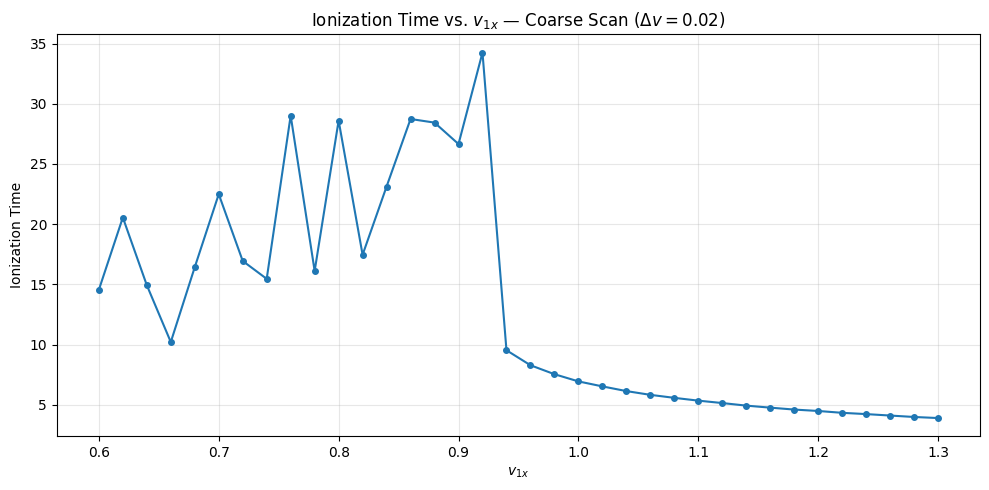

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(v1x_coarse, ion_coarse, 'o-', ms=4, color='tab:blue')
plt.xlabel(r'$v_{1x}$')
plt.ylabel('Ionization Time')
plt.title(r'Ionization Time vs. $v_{1x}$ — Coarse Scan ($\Delta v = 0.02$)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The coarse scan reveals an irregular, spiky pattern. Ionization times are generally longer for smaller $v_{1x}$ and drop off at higher velocities. We now zoom into the region around the longest ionization time to see if the fine structure resembles the coarse structure.

In [21]:
peak_idx = np.argmax(ion_coarse)
v_center = v1x_coarse[peak_idx]
print(f"Longest ionization time: {ion_coarse[peak_idx]:.1f} at v1x = {v_center:.2f}")

v1x_fine = np.arange(v_center - 0.05, v_center + 0.051, 0.002)
ion_fine = np.zeros(len(v1x_fine))

for i, v1x in enumerate(v1x_fine):
    ion_fine[i] = ionization_time(v1x)
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(v1x_fine)}")

print("Fine scan complete.")

Longest ionization time: 34.2 at v1x = 0.92
  Completed 10/51
  Completed 20/51
  Completed 30/51
  Completed 40/51
  Completed 50/51
Fine scan complete.


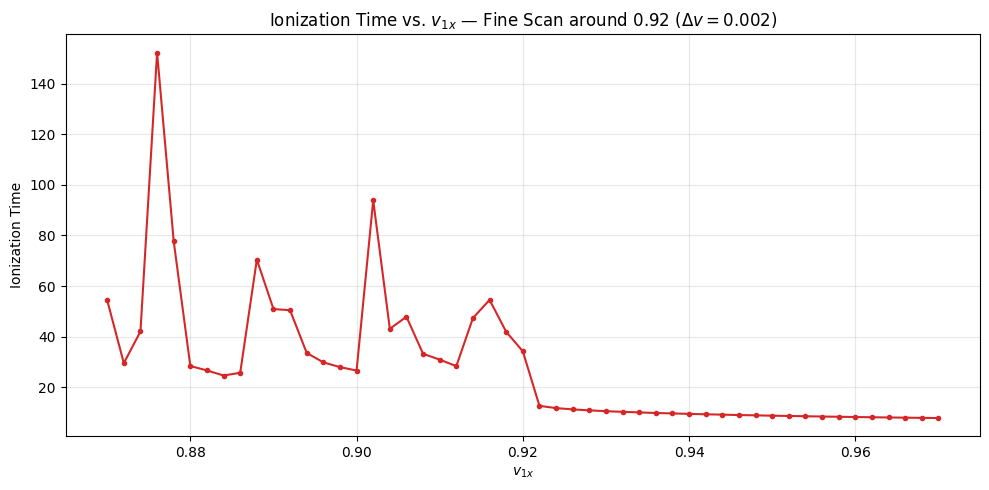

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(v1x_fine, ion_fine, 'o-', ms=3, color='tab:red')
plt.xlabel(r'$v_{1x}$')
plt.ylabel('Ionization Time')
plt.title(f'Ionization Time vs. $v_{{1x}}$ — Fine Scan around {v_center:.2f} ' + r'($\Delta v = 0.002$)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The fine scan reveals the same spiky pattern at a smaller scale, with new peaks appearing that were invisible in the coarse scan. The longest ionization times in the fine scan are significantly longer than those in the coarse scan, which is expected since finer resolution can resolve the narrow peaks more precisely. The qualitative similarity between the two plots, where narrow peaks of long ionization time are separated by regions of fast ionization, is the hallmark of **self-similarity**. This behavior is characteristic of chaotic systems and the geometry of fractals, as discussed by Yamamoto and Kaneko. If we were to zoom in further, we would expect to see the same pattern repeat at even finer scales.

**Interpretation** <br>
The classical helium atom, despite having only two electrons and a fixed nucleus, exhibits a rich variety of dynamical behaviors. In part (a), we saw that certain initial conditions produce stable, planetary-like orbits where the two electrons remain bound. The energy conservation check confirmed that our RK45 implementation with tolerances of $10^{-9}$ is suitable for this problem, maintaining energy to a relative accuracy of $\sim 10^{-8}$ over 50 time units.

In part (b), the braiding orbits demonstrated a qualitatively different mode of motion where both electrons participate equally. The extreme sensitivity to initial conditions, where a change of just $0.02$ in $v_{1y}$ leads to autoionization, highlights the chaotic nature of the three-body problem. This is in contrast to the two-body Kepler problem, which is integrable and does not exhibit chaos.

Part (c) confirmed that angular momentum is conserved to the precision of our numerical method ($\sim 10^{-9}$). This serves as an additional validation of our solver and is physically expected since all forces are central. The complex orbits produced by these initial conditions, particularly the exchange of roles between the two electrons, illustrate the complexity possible in even this simplified model.

The most striking result is the self-similar structure found in part (d). The ionization time as a function of $v_{1x}$ shows fractal-like behavior: zooming into a peak reveals the same spiky structure at a finer scale. This is a well-known signature of chaotic scattering, where the boundary between different outcomes (here, which electron escapes and in which direction) has a fractal structure in phase space. This type of analysis connects the classical helium atom to broader topics in nonlinear dynamics, including fractal geometry (Chapter 13) and chaos (Chapter 6).

An avenue for future exploration would be to extend the simulation to three dimensions, or to use a regularization scheme that handles close encounters with the nucleus more gracefully. One could also compute the fractal dimension of the ionization time curve to quantify the degree of chaos in the system.